In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("../exp8/brand_analysis_dataset.csv")

In [3]:
def get_brand(text):
    if "samsung" in text:
        return "samsung"
    elif "apple" in text:
        return "apple"

In [4]:
df['brand']=df['text'].apply(get_brand)

In [5]:
df=df[df['brand'].isin(['apple','samsung'])]

In [6]:
print(df['brand'].value_counts())

brand
apple      12
samsung     8
Name: count, dtype: int64


In [7]:
df['engagement'] = df['likes'] + df['comments'] + df['shares']

In [8]:
df.head()

,user,text,likes,comments,shares,timestamp,brand,engagement
3,user4,samsung is innovative,34,20,8,2024-02-4,samsung,62
4,user1,apple ecosystem is smooth,41,18,3,2024-02-8,apple,62
5,user1,apple products are too expensive,8,12,6,2024-02-9,apple,26
6,user3,samsung is innovative,65,6,3,2024-02-8,samsung,74
7,user1,apple products are too expensive,12,0,8,2024-02-6,apple,20


In [9]:
post_counts=df['brand'].value_counts()
print(post_counts)

brand
apple      12
samsung     8
Name: count, dtype: int64


In [10]:
engagement_comp=df.groupby('brand')['engagement'].mean()
print(engagement_comp)

brand
apple      49.000
samsung    60.375
Name: engagement, dtype: float64


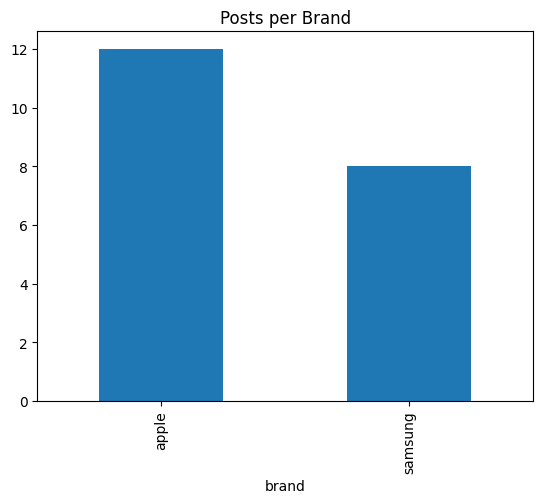

In [11]:
import matplotlib.pyplot as plt
post_counts.plot(kind='bar')
plt.title("Posts per Brand")
plt.show()

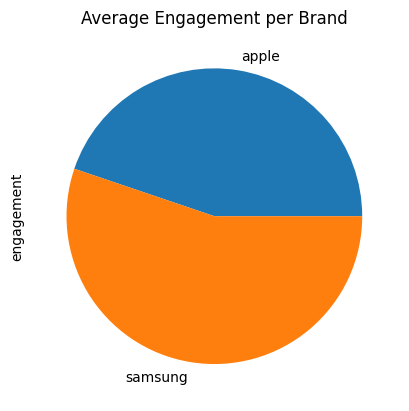

In [12]:
engagement_comp.plot(kind='pie')
plt.title("Average Engagement per Brand")
plt.show()

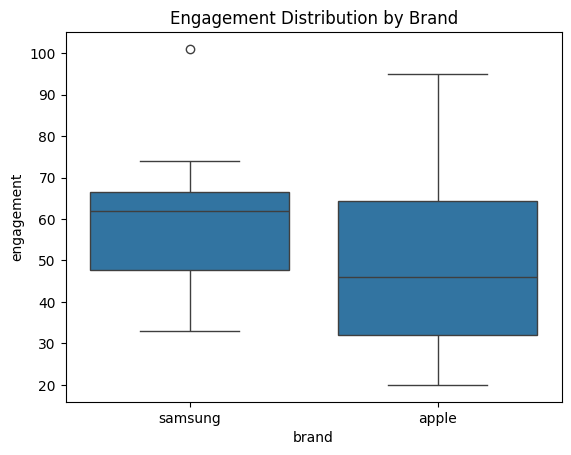

In [14]:
import seaborn as sns
sns.boxplot(x='brand', y='engagement', data=df)
plt.title("Engagement Distribution by Brand")
plt.show()

In [15]:
import networkx as nx
import pandas as pd
import numpy as np
from networkx.algorithms.community import girvan_newman

In [16]:
G=nx.Graph()

In [17]:
for _,row in df.iterrows():
    G.add_edge(row['user'],row['brand'])

In [18]:
communities=girvan_newman(G)

In [19]:
first_level=next(communities)

In [20]:
print(first_level)

({'user3', 'user5', 'user4', 'samsung', 'apple', 'user1'}, {'user2'})


In [21]:
communities_list = [list(c) for c in first_level]

print(communities_list)

[['user3', 'user5', 'user4', 'samsung', 'apple', 'user1'], ['user2']]


In [22]:
from sklearn.cluster import KMeans

In [23]:
X = df[['likes','comments','shares','engagement']]

In [24]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X)

In [25]:
print(df[['likes','engagement','cluster']].head())

   likes  engagement  cluster
3     34          62        0
4     41          62        0
5      8          26        1
6     65          74        2
7     12          20        1


In [26]:
print(df.groupby('cluster')['engagement'].mean())

cluster
0    58.000
1    30.625
2    84.000
Name: engagement, dtype: float64


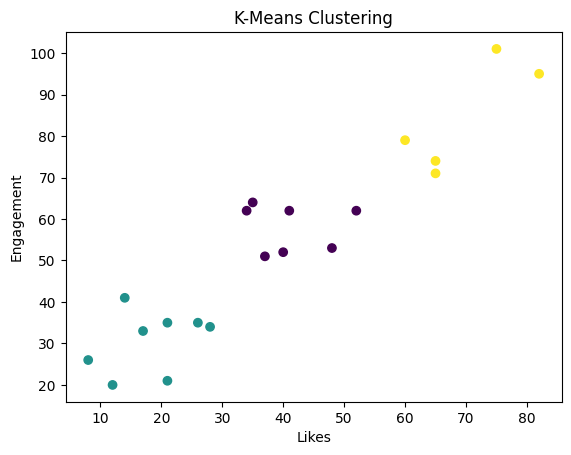

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df['likes'], df['engagement'], c=df['cluster'])
plt.title("K-Means Clustering")
plt.xlabel("Likes")
plt.ylabel("Engagement")
plt.show()

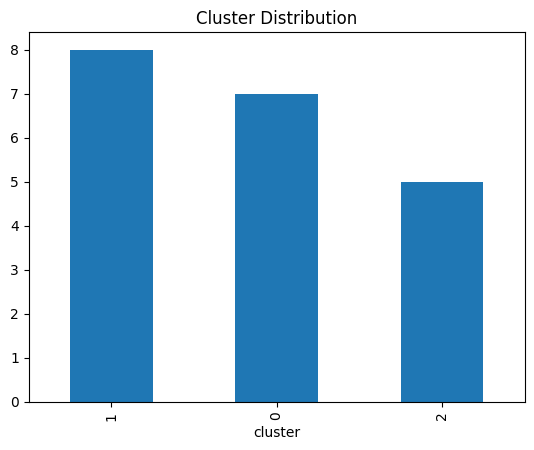

In [28]:
df['cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()